In [5]:
# Import necessary libraries
import os
from src.ode.sm_models_o_e import SynchronousMachineModels
from src.nn.nn_dataset_pre import Datapreprocessor
from src.nn.nn_actions_pre import NeuralNetworkActions
from src.functions import *
from omegaconf import OmegaConf
import wandb
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import gc

gc.collect()

7

In [4]:
run = None

cfg = OmegaConf.load("src/conf/setup_dataset_nn_o_e.yaml")
cfg.nn.weighting.weights = [1, 0, 0, 0]
cfg.nn.num_epochs =5000
cfg.nn.batch_size = 1000
modelling_full = SynchronousMachineModels(cfg)
datapreprocessor = Datapreprocessor(cfg)


network = NeuralNetworkActions(cfg, modelling_full, datapreprocessor)

# Set skip points and start training
num_of_skip_data_points = 23
num_of_skip_col_points = 19
num_of_skip_val_points = 4
    
# Train the network
network.pinn_train(num_of_skip_data_points, num_of_skip_col_points, num_of_skip_val_points, run)

Number of files in the train folder:  8 where  3 are col files and 5 are data files
Number of files in the val folder:  2
Number of files in the test folder:  1
Selected deep learning model:  DynamicNN with configs found in src/conf/setup_nn_model.yaml
dict_items([('hidden_layers', 4), ('hidden_dim', 64)])
⚠️ Warning: torch.compile() is not supported on Windows. Returning uncompiled model.
Number of labeled training data: 1654 Number of collocation points: 3795 Number of collocation points (IC): 72 Number of validation data: 1000
Weights initialized as:  [1, 0, 0, 0]  are updated with scheme:  Static 
getting in training
Validation loss decreased (inf --> 0.116921).  Saving model ...


KeyboardInterrupt: 

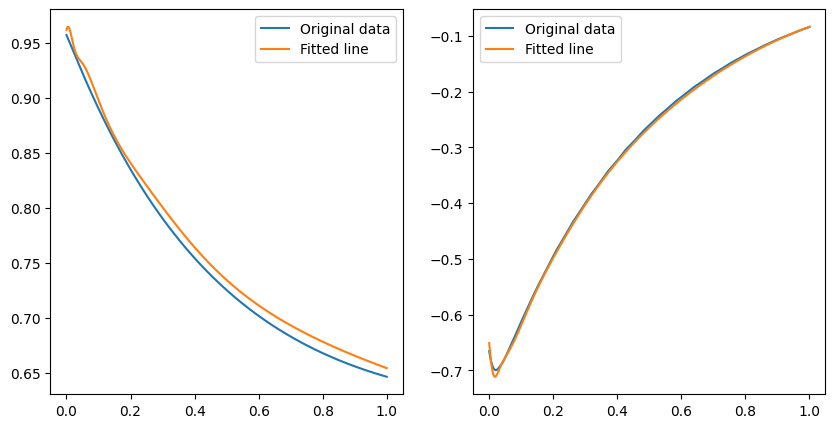

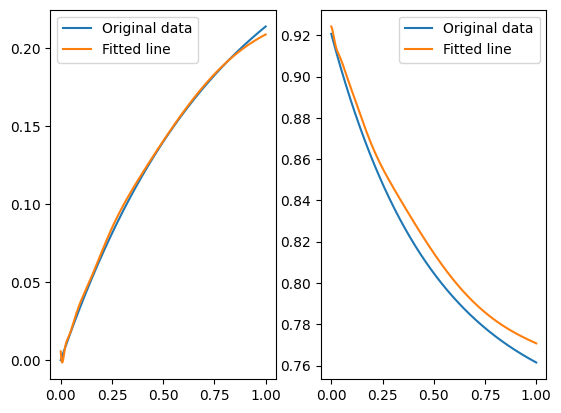

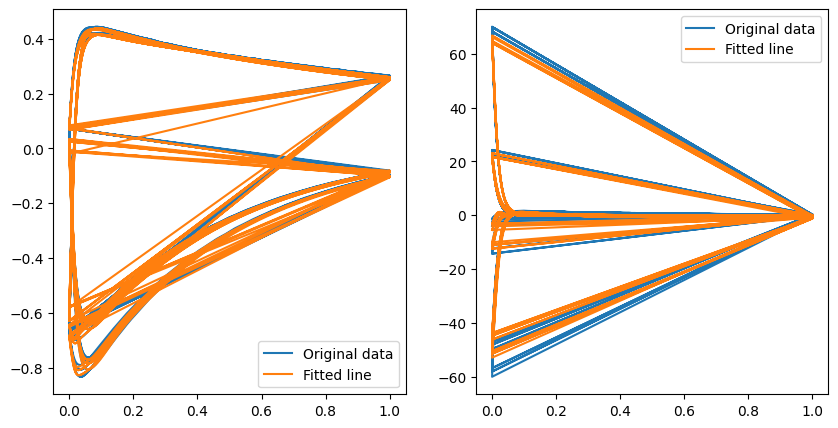

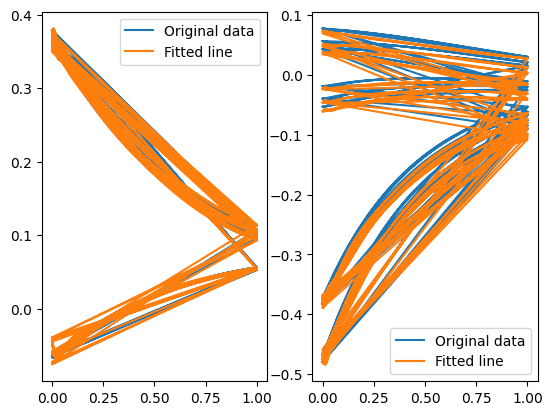

In [20]:
from src.nn.nn_dataset_pre import HDF5DatasetStatic



folder_path = "./"+cfg.dirs.dataset_dir+"/" + cfg.model.model_flag + '/dataset_v' + str(cfg.dataset.number)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_d = HDF5DatasetStatic(folder_path, 'train', step=1, shuffle=False)
x_train, y_train = train_d.x_data.to(device).requires_grad_(True), train_d.y_data.to(device).requires_grad_(True)
network.plot_all(x_train[:1000],y_train[:1000])

network.plot_all_dt(x_train,y_train)

In [24]:
y_pred = network.test(x_train) # Predict the output data
print(x_train.shape, y_train.shape, y_pred.shape)
dt = network.calculate_from_ode(y_train,x_train)  

torch.Size([1654, 8]) torch.Size([1654, 4]) torch.Size([1654, 4])


In [ ]:

# Define the training function
def train_single_scenario():
    # Initialize wandb for logging (optional)
    run = None

    # Load base configuration from YAML
    cfg = OmegaConf.load("src/conf/setup_dataset_nn_o_e.yaml")

    # Define a single configuration scenario
    cfg.seed = 1
    cfg.nn.type = "actnet"  # Options: "DynamicNN", "KAN"
    cfg.nn.weighting.flag_mean_weights = True
    cfg.nn.weighting.update_weight_method = "Static"  # Options: "Gradient", "Static", "Ntk", "Sam"
    cfg.nn.weighting.weights = [1, 0, 0, 0]
    cfg.nn.num_epochs = 1000
    # Adjust settings based on nn_type and optimizer
    if cfg.nn.type == "KAN":
        cfg.nn.hidden_layers = 2
        cfg.nn.hidden_dim = 12
        cfg.nn.num_epochs = int(cfg.nn.num_epochs / 5)

    if cfg.nn.optimizer == "LBFGS":
        lbfgs_iter = 10
        cfg.nn.early_stopping_patience = int(cfg.nn.early_stopping_patience / lbfgs_iter)
        cfg.nn.num_epochs = int(cfg.nn.num_epochs / lbfgs_iter)
        cfg.nn.weighting.update_weights_freq = int(cfg.nn.weighting.update_weights_freq * 4)  # Increase due to internal iterations

    # Initialize model and network
    modelling_full = SynchronousMachineModels(cfg)
    
    network2 = NeuralNetworkActions(cfg, modelling_full)

    # Set skip points and start training
    num_of_skip_data_points = 23
    num_of_skip_col_points = 19
    num_of_skip_val_points = 4

    # Train the network
    network2.pinn_train2(num_of_skip_data_points, num_of_skip_col_points, num_of_skip_val_points, run)
    
    # Finish the wandb run
    if run is not None:
        run.finish()

    return network2

# Run the single scenario
if __name__ == "__main__":
    network2 = train_single_scenario()


SM4_P data_o_e
Loading data from:  ./data_o_e/SM4_P/dataset_v1.pkl
Number of training samples:  19200 Number of validation samples:  2400 Number of testing samples:  2400
Number of different initial conditions for collocation points:  24
['theta', 'omega', 'E_d_dash', 'E_q_dash', 'P_m', 'Vs', 'theta_vs'] Variables
[[-2, 2], [-1, 1], [0], [0.9, 1.1], [0.7], [0.95, 1.05], [-0.3, 0.3]] Set of values for init conditions
[2, 2, 1, 2, 1, 3, 1] Iterations per value
Selected deep learning model:  actnet with configs found in src/conf/setup_nn_model.yaml
dict_items([('num_freqs', 10), ('hidden_dim', 25), ('hidden_layers', 2), ('freq_scaling', True), ('freq_scaling_eps', 0.01), ('freq_scaling_eps_decay', 0.001)])
⚠️ Warning: torch.compile() is not supported on Windows. Returning uncompiled model.
Number of labeled training data: 835 Number of collocation points: 1264 Number of collocation points (IC): 24 Number of validation data: 600
Weights initialized as:  [1, 0, 0, 0]  are updated with schem

In [ ]:

x_train, y_train, x_train_col, x_train_col_ic, y_train_col_ic, x_val, y_val = network2.data_loader.define_train_val_data2(network2.cfg.dataset.perc_of_data_points, network2.cfg.dataset.perc_of_col_points, 4, 1, 1) # define the training and validation data
        
y_hat, y, dy_dt  = network2.calculate_point_grad2(x_train,y_train)

dydt1, ode1 = network2.calculate_point_grad2(x_train_col, None)

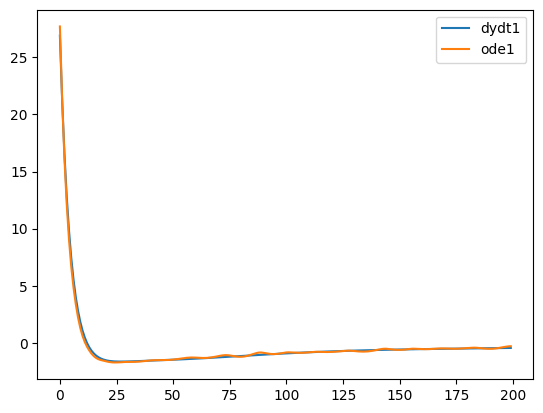

In [35]:
#plot the first 1000 points of dydt1 and ode1 to see if they are the same
#y = y.cpu().detach().numpy()
#dy_dt = dy_dt.cpu().detach().numpy()
plt.plot(y[0:200,1], label = 'dydt1')
plt.plot(dy_dt[0:200,1], label = 'ode1')
plt.legend()

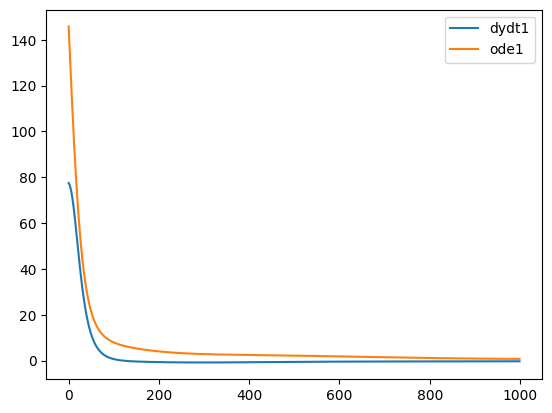

In [40]:
#plot the first 1000 points of dydt1 and ode1 to see if they are the same
#dydt1 = dydt1.cpu().detach().numpy()
#ode1 = ode1.cpu().detach().numpy()
plt.plot(dydt1[0:1000,1], label = 'dydt1')
plt.plot(ode1[0:1000,1], label = 'ode1')
plt.legend()


In [15]:
y1, dy_dt1  = network2.calculate_autograd222(x_train)

dy_dt1[:3]

tensor([[-0.0003, -0.0001,  0.0002,  0.0003],
        [-0.0003, -0.0001,  0.0002,  0.0003],
        [-0.0003, -0.0001,  0.0002,  0.0003]], device='cuda:0')

In [ ]:
import os
from src.ode.sm_models_o_e import SynchronousMachineModels
from src.nn.nn_actions_e import NeuralNetworkActions
from src.functions import *
from omegaconf import OmegaConf
import wandb

def train(config=None):
    run = wandb.init(config=config)
    config = run.config

    # Load base configuration from YAML
    cfg = OmegaConf.load("src/conf/setup_dataset_nn_o_e.yaml")
    cfg.seed = config.seed
    cfg.nn.type = config.nn_type
    cfg.nn.weighting.flag_mean_weights = True
    cfg.nn.weighting.update_weight_method = config.update_weight_method
    cfg.nn.weighting.weights = [config.weight_data, config.weight_dt, config.weight_pinn, config.weight_pinn_ic]
    if cfg.nn.optimizer == "LBFGS":
        lbfgs_iter = 10
        cfg.nn.early_stopping_patience = int(cfg.nn.early_stopping_patience / lbfgs_iter)
        cfg.nn.num_epochs = int(cfg.nn.num_epochs / lbfgs_iter)
        cfg.nn.weighting.update_weights_freq = int(cfg.nn.weighting.update_weights_freq*4) # increase due to internal iterations, around 25 internal iterations per epoch


    # Initialize model and network
    modelling_full = SynchronousMachineModels(cfg)
    network2 = NeuralNetworkActions(cfg, modelling_full)

    # Set skip points and start training
    num_of_skip_data_points = 23
    num_of_skip_col_points = 19
    num_of_skip_val_points = 4

    network2.pinn_train2(num_of_skip_data_points, num_of_skip_col_points, num_of_skip_val_points, run)
    run.finish()

if __name__ == "__main__":
    # Define sweep configuration
    sweep_config = {
        "method": "grid",
        "metric": {
            "name": "Test_loss",
            "goal": "minimize"
        },
        "parameters": {
            "seed": {"values": [1]},
            "nn_type": {"values": ["DynamicNN"]},
            #"flag_mean_weights": {"values": [True, False]},
            "update_weight_method": {"values": ["Static"]},
            "weight_data": {"values": [1]},
            "weight_dt": {"values": [1e-3]},
            "weight_pinn": {"values": [1e-4]},
            "weight_pinn_ic": {"values": [1e-3]}
        }
    }

    # Initialize and run sweep
    sweep_id = wandb.sweep(sweep_config, project="PINN-open-loop")
    wandb.agent(sweep_id, function=train)


Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Create sweep with ID: ay7st4mz
Sweep URL: https://wandb.ai/Rocket-team1/PINN-open-loop/sweeps/ay7st4mz


wandb: Agent Starting Run: 6bs973ki with config:
wandb: 	nn_type: DynamicNN
wandb: 	seed: 1
wandb: 	update_weight_method: Static
wandb: 	weight_data: 1
wandb: 	weight_dt: 0.001
wandb: 	weight_pinn: 0.0001
wandb: 	weight_pinn_ic: 0.001
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: radiakos (Rocket-team1). Use `wandb login --relogin` to force relogin


SM4_P data_o_e
Loading data from:  ./data_o_e/SM4_P/dataset_v1.pkl


c:\Users\Giannis\Desktop\Thesis\Physics-Informed-Neural-Networks-for-Synchronous-Machine-Models\src\nn\nn_dataset.py:230: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ..\torch\csrc\utils\tensor_new.cpp:264.)
  training_sample = torch.tensor(training_sample, dtype=torch.float32) # convert the trajectory to tensor


Number of training samples:  19200 Number of validation samples:  2400 Number of testing samples:  2400
Number of different initial conditions for collocation points:  24
['theta', 'omega', 'E_d_dash', 'E_q_dash', 'P_m', 'Vs', 'theta_vs'] Variables
[[-2, 2], [-1, 1], [0], [0.9, 1.1], [0.7], [0.95, 1.05], [-0.3, 0.3]] Set of values for init conditions
[2, 2, 1, 2, 1, 3, 1] Iterations per value


Run 6bs973ki errored:
Traceback (most recent call last):
  File "c:\Users\Giannis\anaconda30\Lib\site-packages\wandb\agents\pyagent.py", line 307, in _run_job
    self._function()
  File "C:\Users\Giannis\AppData\Local\Temp\ipykernel_176\2311468285.py", line 35, in train
    network2 = NeuralNetworkActions(cfg, modelling_full)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Giannis\Desktop\Thesis\Physics-Informed-Neural-Networks-for-Synchronous-Machine-Models\src\nn\nn_actions_e.py", line 78, in __init__
    self.input_dim = self.modelling_full.keys_length + self.modelling_full.keys_ext_length # The input dimension is the number of input features
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'SynchronousMachineModels' object has no attribute 'keys_length'

wandb: ERROR Run 6bs973ki errored:
wandb: ERROR Traceback (most recent call last):
wandb: ERROR   File "c:\Users\Giannis\anaconda30\Lib\site-packages\wandb\agents\pyagent.py", line 307